<a href="https://colab.research.google.com/github/Shambhuraje1919/Machine_Learning_Paractice/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uditjain13/heart-disease-risk-2026")

print("Path to dataset files:", path)

100%|██████████| 344k/344k [00:00<00:00, 70.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uditjain13/heart-disease-risk-2026/versions/3


In [2]:
import os
import pandas as pd
import numpy as np

In [3]:
os.listdir(path)

['heart_disease_risk_2026.csv']

In [5]:
df = pd.read_csv(os.path.join(path,'heart_disease_risk_2026.csv'))

In [6]:
df.head()

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


In [7]:
df.shape

(9000, 27)

In [9]:
df.tail()

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
8995,8996,36,Female,108,63,178,68,82,158,96,...,False,Never,13.0,306,8.6,51.1,False,7144,58.1,0
8996,8997,44,Female,112,73,213,54,139,102,125,...,False,Former,3.4,76,6.5,37.1,False,7395,68.9,0
8997,8998,57,Female,144,93,198,66,113,79,102,...,False,Never,3.9,194,6.2,46.3,False,7424,70.2,0
8998,8999,61,Female,130,70,220,68,135,109,104,...,False,Former,3.9,139,5.0,66.5,False,5716,43.8,1
8999,9000,63,Female,152,104,215,64,117,109,120,...,False,Never,7.3,95,8.8,54.1,False,3860,54.5,0


In [12]:
df.columns.unique()

Index(['patient_id', 'age', 'sex', 'resting_bp_systolic',
       'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl',
       'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi',
       'resting_heart_rate', 'max_heart_rate_achieved', 'chest_pain_type',
       'exercise_induced_angina', 'st_depression', 'family_history',
       'smoker_status', 'alcohol_units_per_week', 'exercise_minutes_per_week',
       'sleep_hours', 'stress_score', 'wearable_owner', 'daily_steps',
       'diet_quality_score', 'has_heart_disease'],
      dtype='object')

In [16]:
df['has_heart_disease']

,has_heart_disease
0,0
1,1
2,0
3,1
4,1
...,...
8995,0
8996,0
8997,0
8998,1


In [20]:
df.dtypes

,0
patient_id,int64
age,int64
sex,object
resting_bp_systolic,int64
resting_bp_diastolic,int64
cholesterol_total,int64
hdl,int64
ldl,int64
triglycerides,int64
fasting_blood_sugar,int64


In [21]:
df['sex']

,sex
0,Male
1,Male
2,Male
3,Male
4,Female
...,...
8995,Female
8996,Female
8997,Female
8998,Female


In [24]:
df['smoker_status']

,smoker_status
0,Never
1,Never
2,Current
3,Never
4,Former
...,...
8995,Never
8996,Former
8997,Never
8998,Former


In [29]:
df = pd.get_dummies(df, columns = ['smoker_status'],drop_first= True)

In [31]:
df.dtypes

,0
patient_id,int64
age,int64
resting_bp_systolic,int64
resting_bp_diastolic,int64
cholesterol_total,int64
hdl,int64
ldl,int64
triglycerides,int64
fasting_blood_sugar,int64
hba1c,float64


In [32]:
df['chest_pain_type']

,chest_pain_type
0,Asymptomatic
1,Non-Anginal Pain
2,Asymptomatic
3,Asymptomatic
4,Atypical Angina
...,...
8995,Typical Angina
8996,Asymptomatic
8997,Asymptomatic
8998,Asymptomatic


In [33]:
df = pd.get_dummies(df,columns=['chest_pain_type'],drop_first=True)

In [49]:
df.shape

(9000, 30)

In [47]:
x = df.drop('has_heart_disease',axis=1)

In [48]:
x.shape

(9000, 29)

In [88]:
y = df['has_heart_disease'].values

In [89]:
y.shape

(9000,)

In [98]:
y

array([0, 1, 0, ..., 0, 1, 0])

In [112]:
 from sklearn.model_selection import train_test_split
 from sklearn.linear_model import LogisticRegression
 from xgboost import XGBClassifier
 from sklearn.ensemble import RandomForestClassifier
 from sklearn.metrics import accuracy_score, confusion_matrix

In [103]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [104]:
x_train.head(2)

,patient_id,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,stress_score,wearable_owner,daily_steps,diet_quality_score,sex_Male,smoker_status_Former,smoker_status_Never,chest_pain_type_Atypical Angina,chest_pain_type_Non-Anginal Pain,chest_pain_type_Typical Angina
6317,6318,61,133,91,167,53,103,78,103,4.8,...,50.0,True,6654,79.9,False,True,False,True,False,False
740,741,71,125,73,189,55,126,149,83,5.4,...,36.5,False,621,56.0,False,False,False,False,True,False


In [94]:
Logestic_model = LogisticRegression()

In [95]:
Random_forest_model= RandomForestClassifier()

In [96]:
xgboost_model = XGBClassifier()

In [102]:
Logestic_model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [106]:
xgboost_model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [107]:
Random_forest_model.fit(x_train,y_train)

RandomForestClassifier()

In [113]:
pred_y1 = Random_forest_model.predict(x_test)

In [110]:
pred_y2 = Logestic_model.predict(x_test)

In [111]:
pred_y3 = xgboost_model.predict(x_test)

In [122]:
print('Random_Forest_prediction_accuracy', accuracy_score(y_test, pred_y1))
print('Random_Forest_prediction_accuracy', confusion_matrix(y_test, pred_y1))
print('- '*34)
print('XGBoost_prediction_accuracy', accuracy_score(y_test, pred_y2))
print('XGBoost_prediction_accuracy', confusion_matrix(y_test, pred_y2))
print('- '*34)
print('Logistic_prediction_accuracy', accuracy_score(y_test, pred_y3))
print('Logistic_prediction_accuracy', confusion_matrix(y_test, pred_y3))

Random_Forest_prediction_accuracy 0.8844444444444445
Random_Forest_prediction_accuracy [[1176   68]
 [ 140  416]]
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
XGBoost_prediction_accuracy 0.8277777777777777
XGBoost_prediction_accuracy [[1147   97]
 [ 213  343]]
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Logistic_prediction_accuracy 0.8911111111111111
Logistic_prediction_accuracy [[1162   82]
 [ 114  442]]


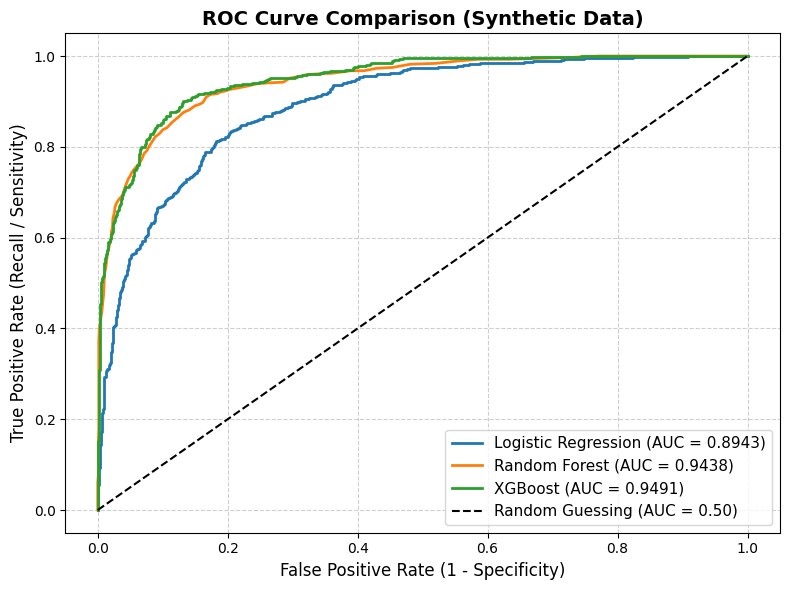

In [126]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Get predicted probabilities for the positive class (column 1)
# Note: For XGBoost, if you are using the scikit-learn API (XGBClassifier), predict_proba works exactly the same way.
pred_prob_lr = Logestic_model.predict_proba(x_test)[:, 1]
pred_prob_rf = Random_forest_model.predict_proba(x_test)[:, 1]
pred_prob_xgb = xgboost_model.predict_proba(x_test)[:, 1]

# 2. Calculate ROC rates and AUC scores
fpr_lr, tpr_lr, _ = roc_curve(y_test, pred_prob_lr)
auc_lr = roc_auc_score(y_test, pred_prob_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, pred_prob_rf)
auc_rf = roc_auc_score(y_test, pred_prob_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, pred_prob_xgb)
auc_xgb = roc_auc_score(y_test, pred_prob_xgb)

# 3. Setup the plot canvas
plt.figure(figsize=(8, 6))

# 4. Plot individual curves with their calculated AUC scores in the legend
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2)

# 5. Plot the baseline diagonal line (random guessing threshold)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.50)')

# 6. Customize chart labels and design aesthetics
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison (Synthetic Data)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# 7. Render layout tightly
plt.tight_layout()
plt.show()

In [127]:
import numpy as np

# Assuming you already computed fpr_xgb, tpr_xgb, and thresholds from roc_curve
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, pred_prob_xgb)

# Calculate Youden's J statistic: J = TPR - FPR
J = tpr_xgb - fpr_xgb
idx = np.argmax(J)
best_thresh = thresholds_xgb[idx]

print(f'Best Threshold for XGBoost: {best_thresh:.4f}')
print(f'Resulting True Positive Rate: {tpr_xgb[idx]:.4f}')
print(f'Resulting False Positive Rate: {fpr_xgb[idx]:.4f}')

Best Threshold for XGBoost: 0.2023
Resulting True Positive Rate: 0.9011
Resulting False Positive Rate: 0.1310
